In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

##### RF DATA ######

print("Loading data")
df1rf = pd.read_csv('results/experiment_results_2013_rf.csv', sep=';')
df1rf = df1rf[df1rf['status'] == 'Success']
df1rf['accuracy'] = df1rf['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)
print("Loading data")

df2rf = pd.read_csv('results/experiment_results_2017_rf.csv', sep=',')
df2rf = df2rf[df2rf['status'] == 'Success']
df2rf['accuracy'] = df2rf['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)

print("Loading data")

df3rf = pd.read_csv('results/experiment_results_2018_rf.csv', sep=',')
df3rf = df3rf[df3rf['status'] == 'Success']
df3rf['accuracy'] = df3rf['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)

print("Loading data")

df4rf = pd.read_csv('results/experiment_results_2019_rf.csv', sep=',')
df4rf = df4rf[df4rf['status'] == 'Success']
df4rf['accuracy'] = df4rf['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)

###### LGBM DATA #####

print("Loading data")
df1lgbm = pd.read_csv('results/experiment_results_2013_lgbm.csv', sep=',')
df1lgbm = df1lgbm[df1lgbm['status'] == 'Success']
df1lgbm['accuracy'] = df1lgbm['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)
print("Loading data")

df2lgbm = pd.read_csv('results/experiment_results_2017_lgbm.csv', sep=',')
df2lgbm = df2lgbm[df2lgbm['status'] == 'Success']
df2lgbm['accuracy'] = df2lgbm['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)

print("Loading data")


df3lgbm = pd.read_csv('results/experiment_results_2018_lgbm.csv', sep=',')
df3lgbm = df3lgbm[df3lgbm['status'] == 'Success']
df3lgbm['accuracy'] = df3lgbm['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)


print("Loading data")

df4lgbm = pd.read_csv('results/experiment_results_2019_lgbm.csv', sep=',')
df4lgbm = df4lgbm[df4lgbm['status'] == 'Success']
df4lgbm['accuracy'] = df4lgbm['accuracy'].apply(lambda x: x / 1000 if x > 1 else x)



Loading data
Loading data
Loading data
Loading data
Loading data
Loading data
Loading data
Loading data


Average Accuracy per Encoding Method per Dataset

📊 Dataset: BPIC 2013 Incidents
--------------------------------------------------
          Random Forest  LightGBM  Overall Avg
Method                                        
Baseline         0.6838    0.6737       0.6787
OHE              0.6867    0.6704       0.6786
Bigram           0.6590    0.6574       0.6582
W2V              0.6663    0.6752       0.6708
D2V              0.6614    0.6341       0.6478
BERT             0.6636    0.6705       0.6671
ACF              0.6415    0.6581       0.6498

📊 Dataset: BPIC 2017
--------------------------------------------------
          Random Forest  LightGBM  Overall Avg
Method                                        
Baseline         0.6194    0.6378       0.6286
OHE              0.6248    0.4361       0.5305
Bigram           0.5438    0.3954       0.4696
W2V              0.7168    0.7179       0.7174
D2V              0.4112    0.3743       0.3928
BERT             0.6964    0.6794       0.6

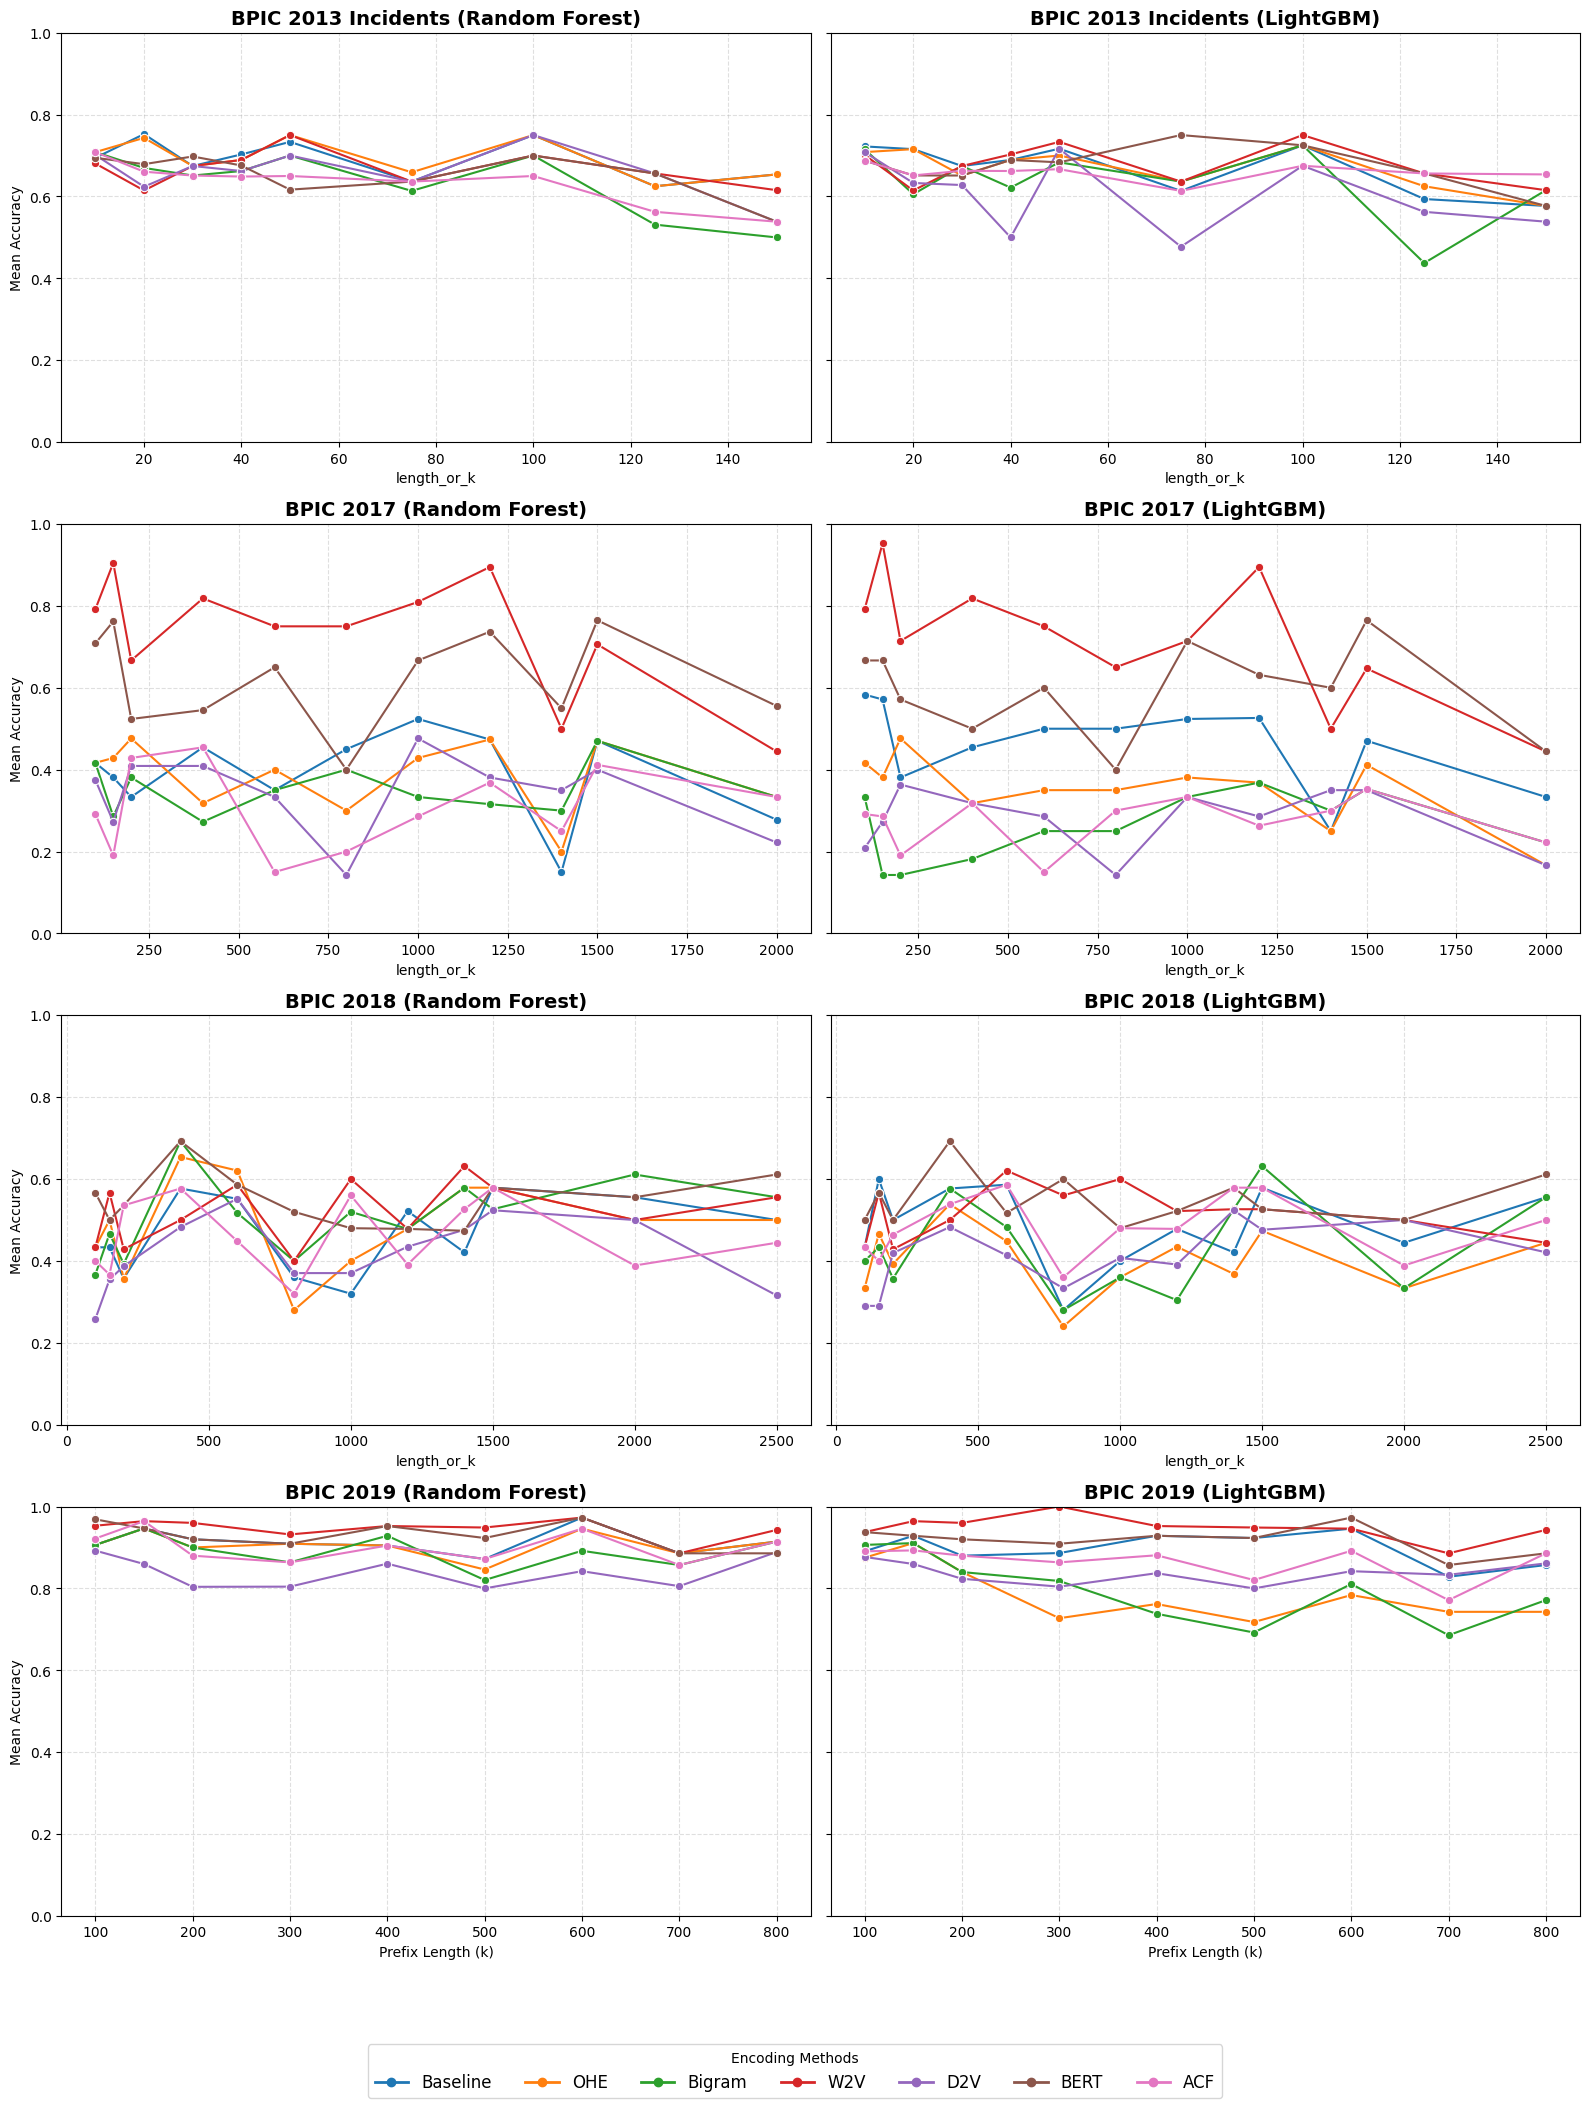

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D


custom_order = ['Baseline', 'OHE', 'Bigram', 'W2V', 'D2V', 'BERT', 'ACF']
colors = sns.color_palette("tab10", len(custom_order))
color_map = dict(zip(custom_order, colors))

grid_dfs = [
    [df1rf, df1lgbm], [df2rf, df2lgbm], 
    [df3rf, df3lgbm],    [df4rf, df4lgbm]
]
dataset_names = ["BPIC 2013 Incidents", "BPIC 2017", "BPIC 2018", "BPIC 2019"]
model_names = ["Random Forest", "LightGBM"]

fig, axes = plt.subplots(4, 2, figsize=(16, 22), sharey=True, sharex='row')


print("=" * 60)
print("Average Accuracy per Encoding Method per Dataset")
print("=" * 60)

for row in range(4):
    dataset_results = {}
    
    for col in range(2):
        df_curr = grid_dfs[row][col]
        
        if df_curr is not None:
            filtered = df_curr[df_curr['strategy'].isin(['prefix', 'last3', 'last5', 'last10', 'last20'])].copy()
            filtered['accuracy'] = filtered['accuracy'].apply(lambda x: x/1000 if x > 1 else x)
            avg_per_method = filtered.groupby('method')['accuracy'].mean()
            dataset_results[model_names[col]] = avg_per_method

    print(f"Dataset: {dataset_names[row]}")
    print("-" * 50)

    summary_df = pd.DataFrame(dataset_results)
    summary_df.index.name = 'Method'

    summary_df = summary_df.reindex([m for m in custom_order if m in summary_df.index])
    summary_df['Overall Avg'] = summary_df.mean(axis=1)
    summary_df = summary_df.round(4)

    print(summary_df.to_string())

for row in range(4):
    for col in range(2):
        ax = axes[row, col]
        df_curr = grid_dfs[row][col]
        
        if df_curr is not None:
            # Filter and normalize (ensure accuracy is 0-1)
            filtered = df_curr[df_curr['strategy'] == 'prefix'].copy()
            print(f"Length filtered is: {len(filtered)}")
            filtered['accuracy'] = filtered['accuracy'].apply(lambda x: x/1000 if x > 1 else x)
            
            plot_data = filtered.groupby(['length_or_k', 'method'])['accuracy'].mean().reset_index()
            print(plot_data)

            sns.lineplot(
                data=plot_data, 
                x='length_or_k', 
                y='accuracy', 
                hue='method', 
                hue_order=custom_order, 
                palette=color_map,
                marker='o',
                ax=ax,
                legend=False 
            )
            
            ax.set_title(f"{dataset_names[row]} ({model_names[col]})", fontsize=14, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.4)
            if col == 0: ax.set_ylabel('Mean Accuracy')
            if row == 3: ax.set_xlabel('Prefix Length (k)')
        else:
            ax.text(0.5, 0.5, 'Results Not Available', ha='center', va='center', color='gray')
            ax.set_title(f"{dataset_names[row]} ({model_names[col]})", color='gray')

plt.ylim(0.0, 1.0)


handles = [
    Line2D([0], [0], color=color_map[method], marker='o', linewidth=2, label=method)
    for method in custom_order
]

fig.legend(
    handles=handles,
    labels=custom_order, 
    loc='lower center',
    bbox_to_anchor=(0.5, 0.02),
    ncol=len(custom_order),
    title='Encoding Methods',
    frameon=True,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.08, 1, 0.98])

plt.savefig(f"plots/4x2_consistent_prefix_results.png", dpi=300)
plt.show()

In [ ]:

all_results = []

for row in range(4):
    for col in range(2):
        df_curr = grid_dfs[row][col]
        
        if df_curr is not None:
            filtered = df_curr[df_curr['strategy'].isin(['prefix', 'last3', 'last5', 'last10', 'last20'])].copy()
            filtered['accuracy'] = filtered['accuracy'].apply(lambda x: x/1000 if x > 1 else x)
            
            stats = filtered.groupby('method')['accuracy'].agg(['mean', 'std']).reset_index()
            
            stats['formatted'] = stats.apply(
                lambda x: f"{x['mean']:.4f} ± {0.0 if pd.isna(x['std']) else x['std']:.4f}", 
                axis=1
            )
            
            for _, row_data in stats.iterrows():
                all_results.append({
                    'Method': row_data['method'],
                    'Model': 'RF' if col == 0 else 'LGBM',
                    'Dataset': dataset_names[row],
                    'Value': row_data['formatted']
                })


master_df = pd.DataFrame(all_results)


final_table = master_df.pivot(
    index=['Method', 'Model'], 
    columns='Dataset', 
    values='Value'
)


existing_methods = [m for m in custom_order if m in final_table.index.get_level_values(0)]
final_table = final_table.reindex(existing_methods, level=0)


model_order = ['RF', 'LGBM']
final_table = final_table.reindex(model_order, level=1)

print("\n" + "="*100)
print("FINAL CONSOLIDATED RESULTS TABLE (MEAN ± SD)")
print("="*100)
print(final_table.to_string())
print("="*100)


FINAL CONSOLIDATED RESULTS TABLE (MEAN ± SD)
Dataset        BPIC 2013 Incidents        BPIC 2017        BPIC 2018        BPIC 2019
Method   Model                                                                       
Baseline RF        0.6838 ± 0.0501  0.6194 ± 0.1771  0.4990 ± 0.0787  0.9346 ± 0.0312
         LGBM      0.6737 ± 0.0580  0.6378 ± 0.1605  0.4932 ± 0.0857  0.9244 ± 0.0397
OHE      RF        0.6867 ± 0.0489  0.6248 ± 0.1774  0.5080 ± 0.0938  0.9364 ± 0.0340
         LGBM      0.6704 ± 0.0565  0.4361 ± 0.1395  0.4061 ± 0.0882  0.7949 ± 0.0702
Bigram   RF        0.6590 ± 0.0600  0.5438 ± 0.1814  0.4946 ± 0.0898  0.9197 ± 0.0353
         LGBM      0.6574 ± 0.0567  0.3954 ± 0.1645  0.4105 ± 0.0938  0.7873 ± 0.0721
W2V      RF        0.6663 ± 0.0421  0.7168 ± 0.1478  0.5259 ± 0.0731  0.9444 ± 0.0249
         LGBM      0.6752 ± 0.0483  0.7179 ± 0.1470  0.5334 ± 0.0708  0.9455 ± 0.0298
D2V      RF        0.6614 ± 0.0591  0.4112 ± 0.1176  0.4400 ± 0.0915  0.8764 ± 0.0396
        

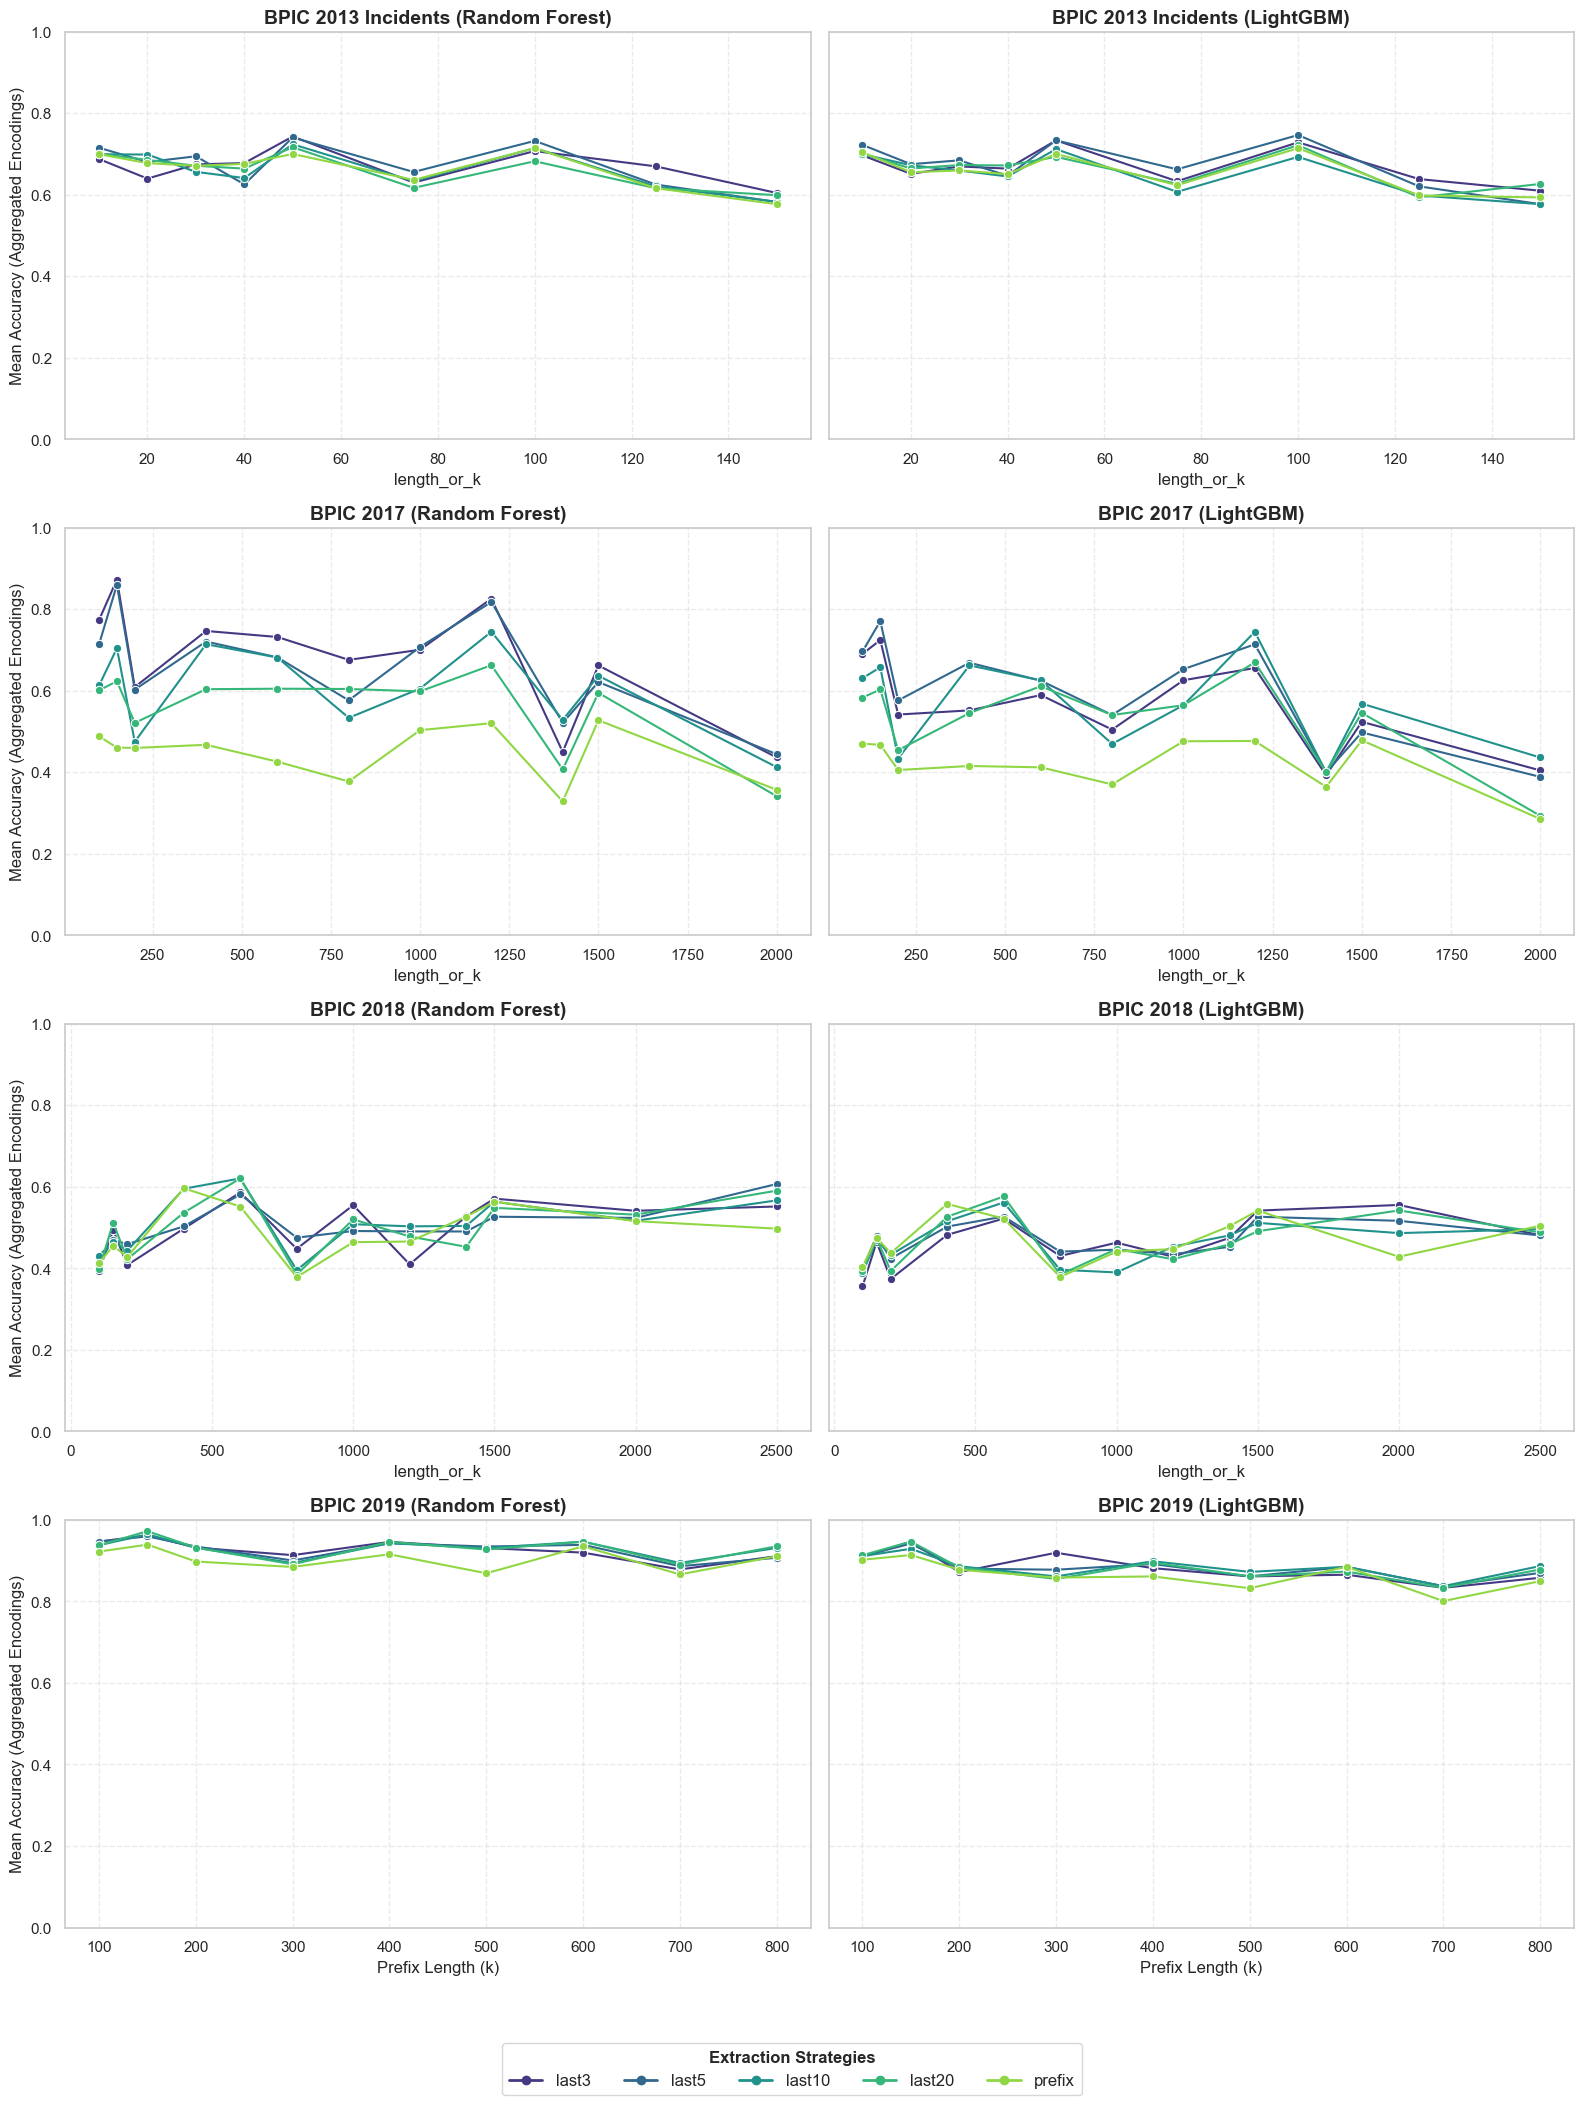

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.lines import Line2D 


strategy_order = ['last3', 'last5', 'last10', 'last20', 'prefix']
strategy_colors = sns.color_palette("viridis", len(strategy_order))

strat_color_map = dict(zip(strategy_order, strategy_colors))

grid_dfs = [
    [df1rf, df1lgbm], [df2rf, df2lgbm], 
    [df3rf, df3lgbm],    [df4rf, df4lgbm]
]
dataset_names = ["BPIC 2013 Incidents", "BPIC 2017", "BPIC 2018", "BPIC 2019"]
model_names = ["Random Forest", "LightGBM"]
save_path = "plots/kelly"
os.makedirs(save_path, exist_ok=True)

fig, axes = plt.subplots(4, 2, figsize=(16, 22), sharey=True, sharex='row')

for row in range(4):
    for col in range(2):
        ax = axes[row, col]
        df_curr = grid_dfs[row][col]
        
        if df_curr is not None:
            df_plot = df_curr.copy()
            df_plot['accuracy'] = df_plot['accuracy'].apply(lambda x: x/1000 if x > 1 else x)
            
            df_filtered = df_plot[df_plot['strategy'].isin(strategy_order)]
            plot_data = df_filtered.groupby(['length_or_k', 'strategy'])['accuracy'].mean().reset_index()

            sns.lineplot(
                data=plot_data, 
                x='length_or_k', 
                y='accuracy', 
                hue='strategy', 
                hue_order=strategy_order,
                palette=strat_color_map, 
                marker='o',
                ax=ax,
                legend=False
            )


            
            ax.set_title(f"{dataset_names[row]} ({model_names[col]})", fontsize=14, fontweight='bold')
            ax.grid(True, linestyle='--', alpha=0.4)
            if col == 0: ax.set_ylabel('Mean Accuracy (Aggregated Encodings)')
            if row == 3: ax.set_xlabel('Prefix Length (k)')
        else:
            ax.text(0.5, 0.5, 'Results Not Available', ha='center', va='center', color='gray', transform=ax.transAxes)
            ax.set_title(f"{dataset_names[row]} ({model_names[col]})", color='gray')

plt.ylim(0.0, 1.0)

legend_elements = [
    Line2D([0], [0], color=strat_color_map[strat], lw=2, marker='o', label=strat) 
    for strat in strategy_order
]

fig.legend(
    handles=legend_elements, 
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.02), 
    ncol=len(strategy_order), 
    title='Extraction Strategies',
    title_fontproperties={'weight':'bold'},
    frameon=True,
    fontsize=12
)

plt.tight_layout(rect=[0, 0.07, 1, 0.98])

plt.savefig(f"{save_path}/4x2_strategy_lineplot_fixed_legend_zoomed_out.png", dpi=300)
plt.show()

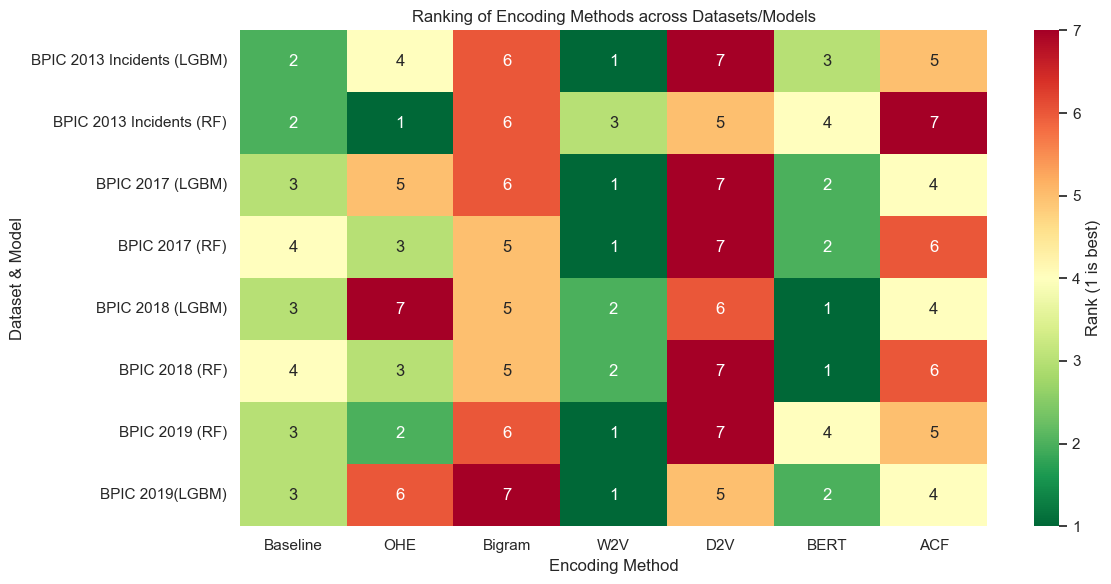

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


all_ranks = []
encodings = ['Baseline', 'OHE', 'Bigram', 'W2V', 'D2V', 'BERT', 'ACF']

for i, df in enumerate(dfs):
    df['accuracy'] = df['accuracy'].apply(lambda x: x/1000 if x > 1 else x)
    
    df_filtered = df[df['method'].isin(encodings)].copy()
    
    mean_scores = df_filtered.groupby('method', observed=False)['accuracy'].mean().reset_index()
    

    mean_scores['rank'] = mean_scores['accuracy'].rank(ascending=False, method='min')
    
    mean_scores['dataset_model'] = df_names[i]
    all_ranks.append(mean_scores)

df_heatmap = pd.concat(all_ranks)

pivot_ranks = df_heatmap.pivot(index='dataset_model', columns='method', values='rank')

pivot_ranks = pivot_ranks[encodings]

plt.figure(figsize=(12, 6))

sns.heatmap(pivot_ranks, annot=True, cmap='RdYlGn_r', fmt='.0f', cbar_kws={'label': 'Rank (1 is best)'})

plt.title('Ranking of Encoding Methods across Datasets/Models')
plt.xlabel('Encoding Method')
plt.ylabel('Dataset & Model')

plt.tight_layout()
plt.show()

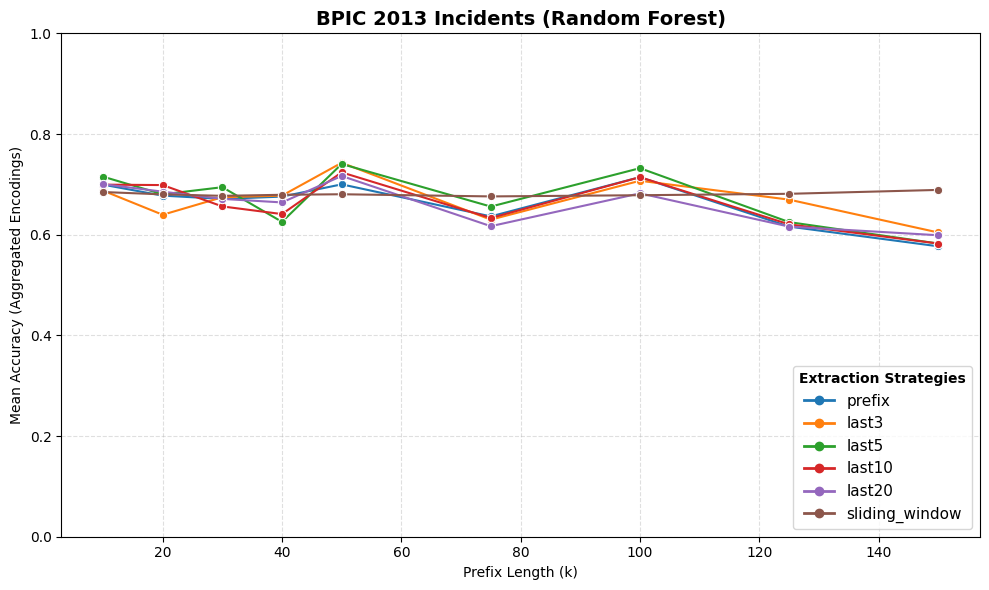

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D

strategy_order = ['prefix', 'last3', 'last5', 'last10', 'last20', 'sliding_window']
strategy_colors = sns.color_palette("tab10", len(strategy_order))
strat_color_map = dict(zip(strategy_order, strategy_colors))

fig, ax = plt.subplots(figsize=(10, 6))

df_plot = df1rf.copy()
df_plot['accuracy'] = df_plot['accuracy'].apply(lambda x: x/1000 if x > 1 else x)

df_filtered = df_plot[df_plot['strategy'].isin(strategy_order)]
plot_data = df_filtered.groupby(['length_or_k', 'strategy'])['accuracy'].mean().reset_index()

sns.lineplot(
    data=plot_data,
    x='length_or_k',
    y='accuracy',
    hue='strategy',
    hue_order=strategy_order,
    palette=strat_color_map,
    marker='o',
    ax=ax,
    legend=True
)

ax.set_title("BPIC 2013 Incidents (Random Forest)", fontsize=14, fontweight='bold')
ax.set_ylabel('Mean Accuracy (Aggregated Encodings)')
ax.set_xlabel('Prefix Length (k)')
ax.grid(True, linestyle='--', alpha=0.4)
ax.set_ylim(0.0, 1.0)

legend_elements = [
    Line2D([0], [0], color=strat_color_map[strat], lw=2, marker='o', label=strat)
    for strat in strategy_order
]
ax.legend(
    handles=legend_elements,
    title='Extraction Strategies',
    title_fontproperties={'weight': 'bold'},
    loc='lower right',
    frameon=True,
    fontsize=11
)

plt.tight_layout()
plt.savefig("plots/kelly/strategy_lineplot_bpic2013_rf.png", dpi=300)
plt.show()

Aggregating data for visualization...


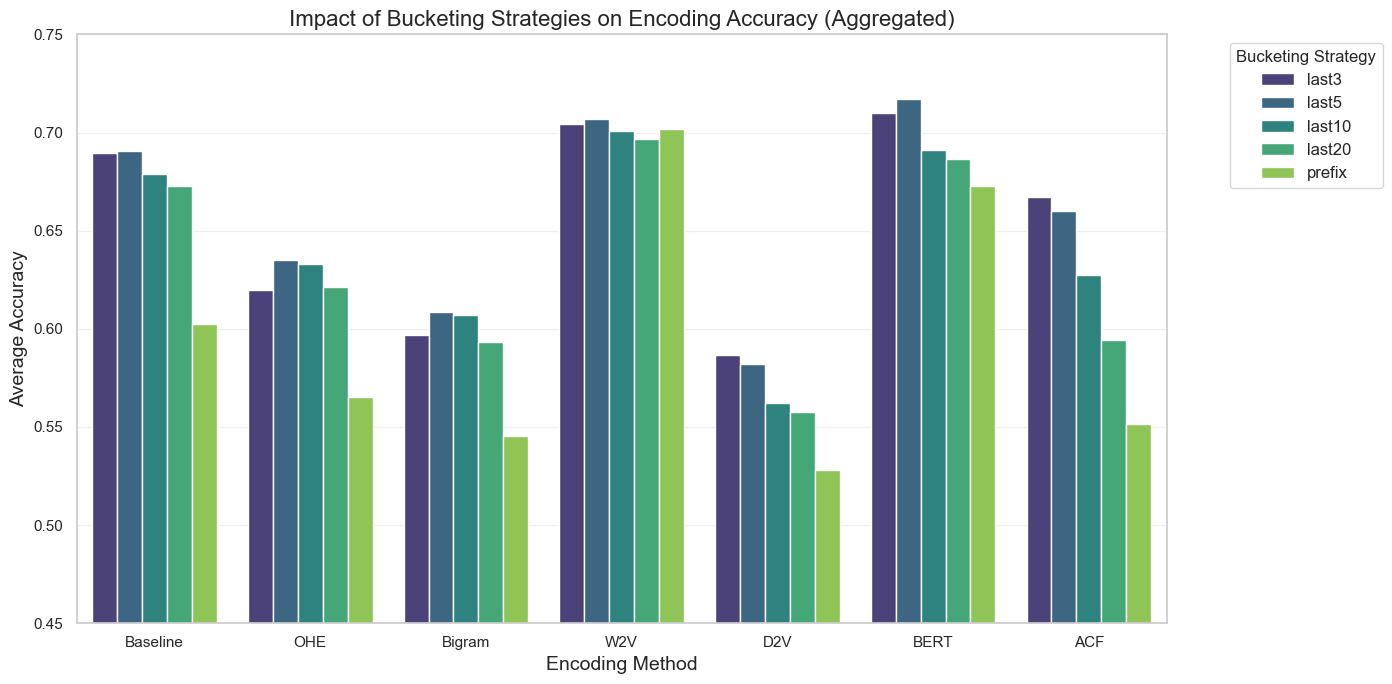

Plot successfully generated and saved as 'bucketing_impact_on_encodings.png'


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



df_all = pd.concat([
    df1rf, df2rf, df3rf, df4rf, 
    df1lgbm, df2lgbm, df3lgbm, df4lgbm
], ignore_index=True)

df_all = df_all[df_all['strategy'] != 'sliding_window']

encodings = ['Baseline', 'OHE', 'Bigram', 'W2V', 'D2V', 'BERT', 'ACF']
df_all = df_all[df_all['method'].isin(encodings)].copy()
df_all['method'] = pd.Categorical(df_all['method'], categories=encodings, ordered=True)

strategies = ['last3', 'last5', 'last10', 'last20', 'prefix']
df_all['strategy'] = pd.Categorical(df_all['strategy'], categories=strategies, ordered=True)

df_agg = df_all.groupby(['method', 'strategy'], observed=False)['accuracy'].mean().reset_index()

plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

sns.barplot(
    data=df_agg,
    x='method',
    y='accuracy',
    hue='strategy',
    palette='viridis'
)

plt.title('Impact of Bucketing Strategies on Encoding Accuracy (Aggregated)', fontsize=16)
plt.ylabel('Average Accuracy', fontsize=14)
plt.xlabel('Encoding Method', fontsize=14)



plt.legend(title='Bucketing Strategy', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title_fontsize=12)

plt.tight_layout()

plt.ylim(0.45, 0.75)

plt.savefig('bucketing_impact_on_encodings.png', dpi=300, bbox_inches='tight')

plt.show()

print("Plot successfully generated and saved as 'bucketing_impact_on_encodings.png'")


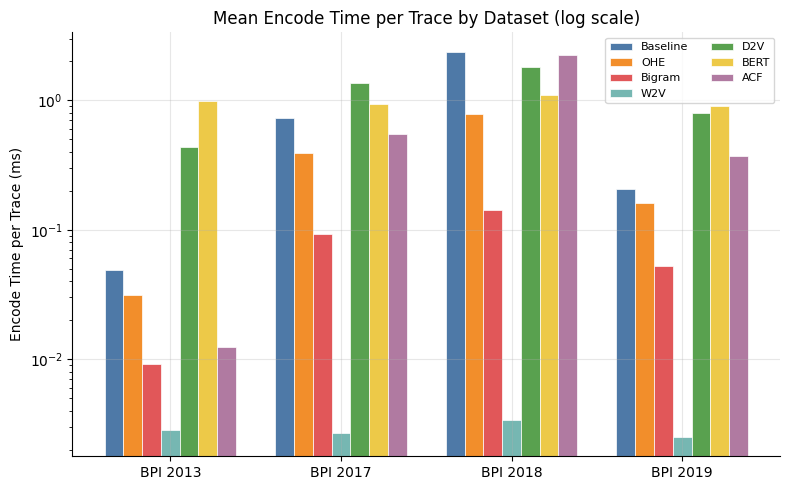

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

FILES = {
    "BPI 2013": "results/encoding_complexity_2013.csv",
    "BPI 2017": "results/encoding_complexity_2017.csv",
    "BPI 2018": "results/encoding_complexity_2018.csv",
    "BPI 2019": "results/encoding_complexity_2019.csv",
}


dfs = []
for label, path in FILES.items():
    df = pd.read_csv(f"{DATA_DIR}/{path}")
    df["dataset_label"] = label
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data["encode_time_per_trace_ms"] = pd.to_numeric(data["encode_time_per_trace_ms"], errors="coerce")

METHOD_ORDER  = ["Baseline", "OHE", "Bigram", "W2V", "D2V", "BERT", "ACF"]
DATASET_ORDER = ["BPI 2013", "BPI 2017", "BPI 2018", "BPI 2019"]

PALETTE = {
    "Baseline": "#4E79A7",
    "OHE":      "#F28E2B",
    "Bigram":   "#E15759",
    "W2V":      "#76B7B2",
    "D2V":      "#59A14F",
    "BERT":     "#EDC948",
    "ACF":      "#B07AA1",
}

pivot = (
    data.groupby(["dataset_label", "method"])["encode_time_per_trace_ms"]
    .mean()
    .unstack("method")
    .reindex(columns=METHOD_ORDER, fill_value=np.nan)
    .reindex(DATASET_ORDER)
)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(DATASET_ORDER))
bar_w = 0.11
for i, method in enumerate(METHOD_ORDER):
    offset = (i - len(METHOD_ORDER) / 2 + 0.5) * bar_w
    ax.bar(x + offset, pivot[method].values, bar_w, label=method,
           color=PALETTE[method], edgecolor="white", linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(DATASET_ORDER)
ax.set_ylabel("Encode Time per Trace (ms)")
ax.set_title("Mean Encode Time per Trace by Dataset (log scale)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.yscale('log')

plt.tight_layout()
plt.savefig("time_complexity_bar.png", dpi=150, bbox_inches="tight")
plt.show()

/var/folders/gc/9ml3w_r92xn0tsh3p0k69h8m0000gn/T/ipykernel_29121/2945923738.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


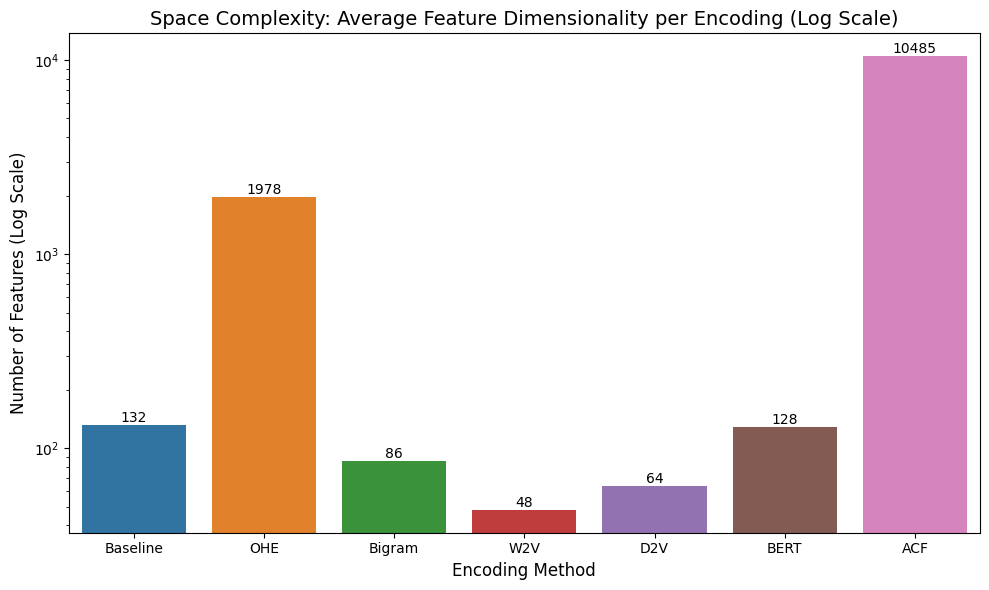

/var/folders/gc/9ml3w_r92xn0tsh3p0k69h8m0000gn/T/ipykernel_29121/2945923738.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


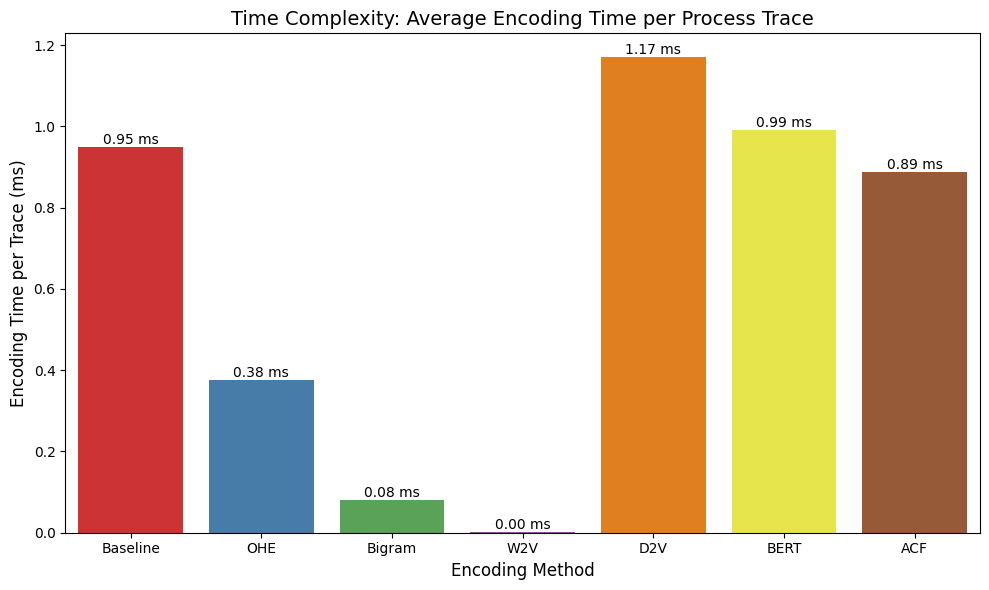


--- Summary Table for Thesis (Mean & SD) ---
  method  n_features_mean  n_features_std  encode_time_per_trace_ms_mean  encode_time_per_trace_ms_std  pretrain_time_seconds_mean  pretrain_time_seconds_std
Baseline           132.19          374.27                           0.95                          4.72                        0.00                       0.00
     OHE          1978.38         5717.56                           0.38                          1.65                        0.00                       0.00
  Bigram            86.11           66.85                           0.08                          0.20                        0.00                       0.00
     W2V            48.00            0.00                           0.00                          0.00                        0.04                       0.09
     D2V            64.00            0.00                           1.17                          2.43                        6.56                       5.82
    BE

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_comp_13 = pd.read_csv('results/encoding_complexity_2013.csv')
df_comp_17 = pd.read_csv('results/encoding_complexity_2017.csv')
df_comp_18 = pd.read_csv('results/encoding_complexity_2018.csv')
df_comp_19 = pd.read_csv('results/encoding_complexity_2019.csv')

df_comp_all = pd.concat([df_comp_13, df_comp_17, df_comp_18, df_comp_19], ignore_index=True)

encodings = ['Baseline', 'OHE', 'Bigram', 'W2V', 'D2V', 'BERT', 'ACF']
df_comp_all = df_comp_all[df_comp_all['method'].isin(encodings)].copy()
df_comp_all['method'] = pd.Categorical(df_comp_all['method'], categories=encodings, ordered=True)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_comp_all, 
    x='method', 
    y='n_features', 
    palette='tab10',
    errorbar=None
)
plt.yscale('log') 
plt.title('Space Complexity: Average Feature Dimensionality per Encoding (Log Scale)', fontsize=14)
plt.ylabel('Number of Features (Log Scale)', fontsize=12)
plt.xlabel('Encoding Method', fontsize=12)

means_features = df_comp_all.groupby('method', observed=False)['n_features'].mean()
for i, mean_val in enumerate(means_features):
    plt.text(i, mean_val, f'{int(mean_val)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('complexity_space_features.png', dpi=300)
plt.show()


plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_comp_all, 
    x='method', 
    y='encode_time_per_trace_ms', 
    palette='Set1',
    errorbar=None
)
plt.title('Time Complexity: Average Encoding Time per Process Trace', fontsize=14)
plt.ylabel('Encoding Time per Trace (ms)', fontsize=12)
plt.xlabel('Encoding Method', fontsize=12)

means_time = df_comp_all.groupby('method', observed=False)['encode_time_per_trace_ms'].mean()
for i, mean_val in enumerate(means_time):
    plt.text(i, mean_val, f'{mean_val:.2f} ms', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('complexity_time_per_trace.png', dpi=300)
plt.show()


summary_table = df_comp_all.groupby('method', observed=False).agg({
    'n_features': ['mean', 'std'],
    'encode_time_per_trace_ms': ['mean', 'std'],
    'pretrain_time_seconds': ['mean', 'std']
}).round(2)

summary_table.columns = [f"{col[0]}_{col[1]}" for col in summary_table.columns]
summary_table = summary_table.reset_index()

numeric_cols = summary_table.select_dtypes(include=['number']).columns
summary_table[numeric_cols] = summary_table[numeric_cols].fillna(0)

print("\n--- Summary Table for Thesis (Mean & SD) ---")
print(summary_table.to_string(index=False))